# EX4 — Subgroup loss comparison: `std_trial_036` vs `feat_trial_015`

Compare the two best-performing models from EX1 and EX3 across patient subgroups on
the 113-patient test set. Subgroups are defined exactly as in
`feature_split_analysis.ipynb` (cell 24): `pd.qcut(q=4, duplicates='drop')` on every
continuous feature, native levels on categorical/binary features.

**Models**
- `std`  — `out/std_trial_036/dice_results.csv` (EX1 best standard UNet)
- `film` — `out/ex3/bayes_search/feat_trial_015/dice_results.csv` (EX3 best FILM model, uses 22 aggregated features)

**Loss compared:** `ssim_l1_loss = 0.8 * ssim_loss + 0.2 * l1_loss` (the actual
training objective; see `utils/model_utils/loss_functions.py:12-17`).

**Two matrices produced:**
- **Matrix A** — subgroups over *all* health + FastSurfer features
- **Matrix B** — subgroups restricted to the 22 features FILM uses (from `selection.json`)


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '.')

# Match analyse_results.py colour conventions for the two model families
STD_COLOR  = '#4C72B0'   # FAMILY_PALETTE['std']
FILM_COLOR = '#17A2B8'   # FAMILY_PALETTE['feat']

PROJECT_ROOT  = Path('.')
STD_DIR       = PROJECT_ROOT / 'out' / 'std_trial_036'
FILM_DIR      = PROJECT_ROOT / 'out' / 'ex3' / 'bayes_search' / 'feat_trial_015'
META_PATH     = PROJECT_ROOT / 'data' / 'metadata' / 'metadata_combined.csv'
FIG_DIR       = PROJECT_ROOT / 'out' / 'overleaf_figures' / 'ex4'
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_MIN = 10  # subgroup-size threshold below which we grey out / drop a cell


## 1 — Load per-patient losses

Both `dice_results.csv` files store the component losses (`ssim_loss`, `l1_loss`).
Reconstruct the combined training loss as `0.8 * ssim + 0.2 * l1`.

In [2]:
def _load_losses(csv_path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['ssim_l1_loss'] = 0.8 * df['ssim_loss'] + 0.2 * df['l1_loss']
    df['model'] = model_name
    df['hunt_id'] = df['patient_id'].astype(str).str.zfill(5)
    return df

std_df  = _load_losses(STD_DIR  / 'dice_results.csv', 'std')
film_df = _load_losses(FILM_DIR / 'dice_results.csv', 'film')

losses = pd.concat([std_df, film_df], ignore_index=True)
print(f'std  : {len(std_df):3d} patients  | mean ssim_l1_loss = {std_df.ssim_l1_loss.mean():.4f}')
print(f'film : {len(film_df):3d} patients  | mean ssim_l1_loss = {film_df.ssim_l1_loss.mean():.4f}')

shared = set(std_df.hunt_id) & set(film_df.hunt_id)
assert len(shared) == len(std_df) == len(film_df),     f'patient sets diverge — std={len(std_df)} film={len(film_df)} shared={len(shared)}'
print(f'shared patients: {len(shared)}')

losses.head()


std  : 113 patients  | mean ssim_l1_loss = 0.0532
film : 113 patients  | mean ssim_l1_loss = 0.0514
shared patients: 113


,patient_id,dice_GM,dice_WM,dice_CSF,vs_GM,vs_WM,vs_CSF,ssim_loss,l1_loss,ssim_l1_loss,model,hunt_id
0,14968,0.522361,0.660252,0.686125,0.972077,0.972260,0.902245,0.048538,0.012954,0.041421,std,14968
1,16086,0.694747,0.808685,0.843904,0.978906,0.999758,0.941284,0.179039,0.026914,0.148614,std,16086
2,14487,0.745975,0.850233,0.745708,0.983202,0.956383,0.765941,0.125362,0.022149,0.104719,std,14487
3,20391,0.769413,0.858980,0.933451,0.998574,0.982705,0.980656,0.107864,0.022252,0.090741,std,20391
4,25219,0.783118,0.878766,0.756825,0.982956,0.964755,0.771572,0.097002,0.018634,0.081328,std,25219


## 2 — Load patient metadata and recover categorical levels

`metadata_combined.csv` is min-max normalised and one-hot encoded. For subgroup
labelling we need:
- the **single integer level** for each one-hot-encoded categorical
- the raw 0/1 for binary features
- the normalised continuous values (qcut is rank-based so this is fine)


In [3]:
meta = pd.read_csv(META_PATH, dtype={'hunt_id': str})
meta['hunt_id'] = meta['hunt_id'].str.zfill(5)
print(f'metadata: {len(meta)} subjects × {len(meta.columns)} columns')

def _recover_categorical(df: pd.DataFrame, prefix: str) -> pd.Series:
    """Return the integer level for a one-hot-encoded categorical."""
    onehot_cols = sorted([c for c in df.columns if c.startswith(prefix + '_')])
    levels      = [int(c.split('_')[-1]) for c in onehot_cols]
    arr         = df[onehot_cols].values
    # argmax picks the active level; if a row is all-zeros (missing) -> NaN
    active_mask = arr.sum(axis=1) > 0
    out         = np.full(len(df), np.nan)
    out[active_mask] = np.array(levels)[arr[active_mask].argmax(axis=1)]
    return pd.Series(out, index=df.index, name=prefix)

for prefix in ['Healt@NT3BLQ1', 'SmoStat@NT3BLQ1', 'Educ@NT2BLQ1']:
    meta[prefix] = _recover_categorical(meta, prefix)

# Inner-join to the 113 test patients
test_ids = sorted(set(losses['hunt_id']))
meta_test = meta[meta['hunt_id'].isin(test_ids)].reset_index(drop=True)
print(f'test-set metadata join: {len(meta_test)} / {len(test_ids)} patients')
assert len(meta_test) == len(test_ids), 'missing metadata for some test patients'
meta_test.head()


metadata: 731 subjects × 39 columns
test-set metadata join: 113 / 113 patients


,hunt_id,Sex,BirthYear,DiaEv@NT3BLQ1,SmoPackYrs@NT3BLQ1,WaistCirc@NT3BLM,HipCirc@NT3BLM,BPDiasMn23@NT3BLM,BPSystMn23@NT3BLM,SeGluNonFast@NT3BLM,...,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total,Healt@NT3BLQ1,SmoStat@NT3BLQ1,Educ@NT2BLQ1
0,18098,1,0.9375,0,0.000000,0.323944,0.422222,0.347222,0.381818,0.317164,...,0.734502,0.801821,0.790036,0.554041,0.663868,0.719455,0.791585,4.0,0.0,4.0
1,24767,1,0.3125,0,0.043478,0.647887,0.644444,0.319444,0.418182,0.220149,...,0.548511,0.561012,0.542995,0.530874,0.593733,0.437464,0.630223,3.0,1.0,2.0
2,16918,0,0.5625,0,0.139130,0.478873,0.600000,0.597222,0.418182,0.261194,...,0.661541,0.683938,0.571752,0.460532,0.410026,0.598097,0.630711,2.0,1.0,2.0
3,24958,0,0.9375,0,0.156522,0.309859,0.466667,0.138889,0.200000,0.257463,...,0.556920,0.701278,0.492465,0.545840,0.590961,0.578905,0.579656,4.0,1.0,5.0
4,23686,0,0.3750,0,0.222609,0.478873,0.444444,0.111111,0.290909,0.201493,...,0.484304,0.721842,0.563016,0.534799,0.501235,0.638034,0.527528,2.0,1.0,2.0


## 3 — Feature type classification

Identical to `feature_split_analysis.ipynb` cell `cfg`, extended with FastSurfer
brain features (all continuous).

In [4]:
CONTINUOUS_HEALTH = [
    'BirthYear', 'SmoPackYrs@NT3BLQ1', 'WaistCirc@NT3BLM', 'HipCirc@NT3BLM',
    'BPDiasMn23@NT3BLM', 'BPSystMn23@NT3BLM', 'SeGluNonFast@NT3BLM',
    'Bmi@NT3BLM', 'HADSTotExtr@NT3BLQ2',
]
CATEGORICAL = ['Healt@NT3BLQ1', 'SmoStat@NT3BLQ1', 'Educ@NT2BLQ1']
BINARY      = ['Sex', 'DiaEv@NT3BLQ1', 'WorCu@NT3BLI']

CONTINUOUS_FASTSURFER = [
    'wmh_volume',
    'frontal_thickness_mean', 'frontal_volume_total',
    'parietal_thickness_mean', 'parietal_volume_total',
    'temporal_thickness_mean', 'temporal_volume_total',
    'occipital_thickness_mean', 'occipital_volume_total',
    'insula_thickness_mean',   'insula_volume_total',
]

CONTINUOUS = CONTINUOUS_HEALTH + CONTINUOUS_FASTSURFER
ALL_FEATURES = CONTINUOUS + CATEGORICAL + BINARY
print(f'{len(CONTINUOUS)} continuous, {len(CATEGORICAL)} categorical, {len(BINARY)} binary  →  {len(ALL_FEATURES)} total')


20 continuous, 3 categorical, 3 binary  →  26 total


## 4 — Build the long-form subgroup table

One row per `(hunt_id, feature, subgroup_label)`. This is the join key for both
matrices — Matrix A keeps every row, Matrix B filters by the FILM-22 set.

Bin labels follow the existing convention: `'Subgroup 0' … 'Subgroup 3'`. When
`pd.qcut(duplicates='drop')` collapses bins (e.g. zero-inflated `SmoPackYrs`),
fewer than 4 labels result — that's the desired behaviour.

In [5]:
def _label_subgroup(series: pd.Series, feature: str, kind: str) -> pd.Series:
    if kind == 'binary':
        return series.map(lambda v: f'{feature}={int(v)}' if pd.notna(v) else np.nan)
    if kind == 'categorical':
        return series.map(lambda v: f'{feature}={int(v)}' if pd.notna(v) else np.nan)
    # continuous — same call as feature_split_analysis cell 24
    bins = pd.qcut(series, q=4, labels=False, duplicates='drop')
    return bins.map(lambda b: f'Subgroup {int(b)}' if pd.notna(b) else np.nan)

def build_subgroups_long(meta_df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    long_rows = []
    for feat in features:
        if feat in BINARY:
            kind = 'binary'
        elif feat in CATEGORICAL:
            kind = 'categorical'
        elif feat in CONTINUOUS:
            kind = 'continuous'
        else:
            raise KeyError(f'feature {feat!r} not classified')
        labels = _label_subgroup(meta_df[feat], feat, kind)
        long_rows.append(pd.DataFrame({
            'hunt_id'        : meta_df['hunt_id'].values,
            'feature'        : feat,
            'feature_kind'   : kind,
            'subgroup_label' : labels.values,
        }))
    return pd.concat(long_rows, ignore_index=True).dropna(subset=['subgroup_label'])

subgroups_long = build_subgroups_long(meta_test, ALL_FEATURES)
print(f'subgroups_long: {len(subgroups_long)} rows ({subgroups_long.feature.nunique()} features)')
subgroups_long.head()


subgroups_long: 2938 rows (26 features)


,hunt_id,feature,feature_kind,subgroup_label
0,18098,BirthYear,continuous,Subgroup 3
1,24767,BirthYear,continuous,Subgroup 0
2,16918,BirthYear,continuous,Subgroup 2
3,24958,BirthYear,continuous,Subgroup 3
4,23686,BirthYear,continuous,Subgroup 1


## 5 — Aggregate to `(feature × subgroup × model)` with subgroup n

Join `subgroups_long` with `losses` so every patient's loss is replicated across
every feature/subgroup they fall in, then groupby-aggregate.

In [6]:
def aggregate_subgroup_losses(subgroups_long: pd.DataFrame,
                              losses: pd.DataFrame) -> pd.DataFrame:
    joined = subgroups_long.merge(losses, on='hunt_id', how='inner')
    agg = (joined
           .groupby(['feature', 'feature_kind', 'subgroup_label', 'model'])
           .agg(mean_loss = ('ssim_l1_loss', 'mean'),
                std_loss  = ('ssim_l1_loss', 'std'),
                n         = ('ssim_l1_loss', 'size'),
                mean_ssim_loss = ('ssim_loss', 'mean'),
                mean_l1_loss   = ('l1_loss',   'mean'),
                mean_ssim_l1_loss = ('ssim_l1_loss', 'mean'),
                mean_dice_GM  = ('dice_GM',  'mean'),
                mean_dice_WM  = ('dice_WM',  'mean'),
                mean_dice_CSF = ('dice_CSF', 'mean'),
                mean_vs_GM    = ('vs_GM',    'mean'),
                mean_vs_WM    = ('vs_WM',    'mean'),
                mean_vs_CSF   = ('vs_CSF',   'mean'),
           )
           .reset_index())
    # divide n by 2 — each patient was joined to both models, but n should
    # reflect the subgroup size, not (subgroup × models). Since we group by
    # model, the per-(feature, subgroup, model) n already equals subgroup size.
    return agg

summary = aggregate_subgroup_losses(subgroups_long, losses)
print(f'summary rows: {len(summary)}  ({summary.feature.nunique()} features × subgroups × 2 models)')
summary.head(10)


summary rows: 200  (26 features × subgroups × 2 models)


,feature,feature_kind,subgroup_label,model,mean_loss,std_loss,n,mean_ssim_loss,mean_l1_loss,mean_ssim_l1_loss,mean_dice_GM,mean_dice_WM,mean_dice_CSF,mean_vs_GM,mean_vs_WM,mean_vs_CSF
0,BPDiasMn23@NT3BLM,continuous,Subgroup 0,film,0.049500,0.010952,32,0.058202,0.014692,0.049500,0.834664,0.912956,0.913855,0.989820,0.968254,0.954610
1,BPDiasMn23@NT3BLM,continuous,Subgroup 0,std,0.051353,0.010563,32,0.060542,0.014595,0.051353,0.834155,0.912099,0.912377,0.994127,0.970689,0.951640
2,BPDiasMn23@NT3BLM,continuous,Subgroup 1,film,0.052572,0.019953,27,0.061860,0.015416,0.052572,0.841042,0.918219,0.908918,0.989613,0.967670,0.940938
3,BPDiasMn23@NT3BLM,continuous,Subgroup 1,std,0.054473,0.019692,27,0.064396,0.014782,0.054473,0.838770,0.916806,0.910862,0.992994,0.969776,0.944269
4,BPDiasMn23@NT3BLM,continuous,Subgroup 2,film,0.052724,0.013950,27,0.062182,0.014889,0.052724,0.839745,0.917666,0.908893,0.990202,0.966342,0.939585
5,BPDiasMn23@NT3BLM,continuous,Subgroup 2,std,0.054770,0.013385,27,0.064770,0.014766,0.054770,0.837420,0.915860,0.906017,0.994654,0.967594,0.936898
6,BPDiasMn23@NT3BLM,continuous,Subgroup 3,film,0.050973,0.008499,27,0.060087,0.014519,0.050973,0.839173,0.919273,0.925866,0.990610,0.965914,0.959665
7,BPDiasMn23@NT3BLM,continuous,Subgroup 3,std,0.052588,0.008535,27,0.062185,0.014200,0.052588,0.837830,0.918052,0.924348,0.994249,0.967467,0.960059
8,BPSystMn23@NT3BLM,continuous,Subgroup 0,film,0.047046,0.005209,33,0.055342,0.013863,0.047046,0.851412,0.925111,0.928300,0.991492,0.967746,0.962722
9,BPSystMn23@NT3BLM,continuous,Subgroup 0,std,0.049323,0.004708,33,0.058203,0.013804,0.049323,0.849938,0.923727,0.926008,0.994928,0.969671,0.959433


### Sanity checks

1. Each `(feature, subgroup_label)` should have exactly 2 rows (one per model).
2. For each feature, the sum of subgroup n (per model) should equal the number
   of non-NaN patients for that feature (≤ 113).

In [7]:
# Check (1)
counts_per_cell = summary.groupby(['feature', 'subgroup_label']).size()
assert (counts_per_cell == 2).all(), 'some cells missing a model'

# Check (2)
totals = (summary[summary.model == 'std']
          .groupby('feature')['n'].sum()
          .sort_values())
print('Patients covered per feature (after dropping NaN subgroups):')
print(totals.to_string())


Patients covered per feature (after dropping NaN subgroups):
feature
BPDiasMn23@NT3BLM           113
BPSystMn23@NT3BLM           113
BirthYear                   113
Bmi@NT3BLM                  113
DiaEv@NT3BLQ1               113
Educ@NT2BLQ1                113
HADSTotExtr@NT3BLQ2         113
Healt@NT3BLQ1               113
HipCirc@NT3BLM              113
SeGluNonFast@NT3BLM         113
Sex                         113
SmoPackYrs@NT3BLQ1          113
SmoStat@NT3BLQ1             113
WaistCirc@NT3BLM            113
WorCu@NT3BLI                113
frontal_thickness_mean      113
frontal_volume_total        113
insula_thickness_mean       113
insula_volume_total         113
occipital_thickness_mean    113
occipital_volume_total      113
parietal_thickness_mean     113
parietal_volume_total       113
temporal_thickness_mean     113
temporal_volume_total       113
wmh_volume                  113


### Paired delta (FILM − Std) per subgroup

Since both models score the same patients, compute the paired delta directly
from the per-patient losses (not from the means) for a tighter estimate.

In [8]:
def paired_delta_per_subgroup(subgroups_long: pd.DataFrame,
                              losses: pd.DataFrame) -> pd.DataFrame:
    wide = (losses.pivot_table(index='hunt_id', columns='model',
                               values='ssim_l1_loss')
                 .rename(columns={'std':'loss_std','film':'loss_film'}))
    wide['delta'] = wide['loss_film'] - wide['loss_std']
    joined = subgroups_long.merge(wide.reset_index(), on='hunt_id', how='inner')
    out = (joined.groupby(['feature','feature_kind','subgroup_label'])
                 .agg(mean_delta = ('delta', 'mean'),
                      std_delta  = ('delta', 'std'),
                      n          = ('delta', 'size'),
                      mean_std_loss  = ('loss_std',  'mean'),
                      mean_film_loss = ('loss_film', 'mean'),
                 )
                 .reset_index())
    return out

deltas = paired_delta_per_subgroup(subgroups_long, losses)
print(f'deltas: {len(deltas)} subgroups')
deltas.sort_values('mean_delta').head(10)


deltas: 100 subgroups


,feature,feature_kind,subgroup_label,mean_delta,std_delta,n,mean_std_loss,mean_film_loss
21,Educ@NT2BLQ1,categorical,Educ@NT2BLQ1=3,-0.002645,0.001934,7,0.049954,0.047309
11,BirthYear,continuous,Subgroup 3,-0.002584,0.001290,23,0.048578,0.045994
35,HipCirc@NT3BLM,continuous,Subgroup 2,-0.002291,0.001473,34,0.050623,0.048332
4,BPSystMn23@NT3BLM,continuous,Subgroup 0,-0.002278,0.001976,33,0.049323,0.047046
38,SeGluNonFast@NT3BLM,continuous,Subgroup 1,-0.002232,0.001887,29,0.051623,0.049391
13,Bmi@NT3BLM,continuous,Subgroup 1,-0.002207,0.001092,30,0.051011,0.048805
58,frontal_thickness_mean,continuous,Subgroup 2,-0.002202,0.001510,28,0.056151,0.053949
94,temporal_volume_total,continuous,Subgroup 2,-0.002173,0.001368,28,0.048932,0.046759
63,frontal_volume_total,continuous,Subgroup 3,-0.002153,0.001100,28,0.051008,0.048855
87,parietal_volume_total,continuous,Subgroup 3,-0.002152,0.001061,28,0.051294,0.049142


## 6 — FILM-22 feature mapping

`selection.json` stores aggregated names (e.g. `Smoking Status`). Map each to its
column in `metadata_combined.csv`.

In [9]:
FILM_AGG_TO_COL = {
    # Health survey
    'Sex'           : 'Sex',
    'BirthYear'     : 'BirthYear',
    'WaistCirc'     : 'WaistCirc@NT3BLM',
    'Smoking Status': 'SmoStat@NT3BLQ1',
    'Education'     : 'Educ@NT2BLQ1',
    'SmoPackYrs'    : 'SmoPackYrs@NT3BLQ1',
    'Health'        : 'Healt@NT3BLQ1',
    'WorCu'         : 'WorCu@NT3BLI',
    'BPDiasMn23'    : 'BPDiasMn23@NT3BLM',
    'BPSystMn23'    : 'BPSystMn23@NT3BLM',
    'HADSTotExtr'   : 'HADSTotExtr@NT3BLQ2',
    'SeGluNonFast'  : 'SeGluNonFast@NT3BLM',
    'DiaEv'         : 'DiaEv@NT3BLQ1',
    # FastSurfer (spaces → underscores)
    'insula volume total'       : 'insula_volume_total',
    'parietal thickness mean'   : 'parietal_thickness_mean',
    'occipital volume total'    : 'occipital_volume_total',
    'insula thickness mean'     : 'insula_thickness_mean',
    'temporal volume total'     : 'temporal_volume_total',
    'wmh volume'                : 'wmh_volume',
    'temporal thickness mean'   : 'temporal_thickness_mean',
    'frontal thickness mean'    : 'frontal_thickness_mean',
    'occipital thickness mean'  : 'occipital_thickness_mean',
}

selection = json.load(open(FILM_DIR / 'selection.json'))
kept_agg = selection['kept_aggregated']
assert set(kept_agg) == set(FILM_AGG_TO_COL),     f'mapping mismatch: missing={set(kept_agg)-set(FILM_AGG_TO_COL)}, extra={set(FILM_AGG_TO_COL)-set(kept_agg)}'

FILM_22 = [FILM_AGG_TO_COL[k] for k in kept_agg]
for col in FILM_22:
    assert col in meta_test.columns, f'{col} missing from metadata'
print(f'FILM-22 columns all present in metadata: {len(FILM_22)} features')


FILM-22 columns all present in metadata: 22 features


## 7 — Visualization helpers

Custom heatmap and delta-bar implementations (the project's existing
`plot_heatmap()` is GM/WM/CSF-shaped, not subgroup-shaped, but we match its
`YlOrRd` (lower-is-better) colour convention).

In [10]:
HIGHER_BETTER_METRICS = ['mean_dice_GM','mean_dice_WM','mean_dice_CSF',
                         'mean_vs_GM','mean_vs_WM','mean_vs_CSF']
LOWER_BETTER_METRICS  = ['mean_ssim_loss','mean_l1_loss','mean_ssim_l1_loss']
METRIC_LABEL = {
    'mean_dice_GM':'dice_GM','mean_dice_WM':'dice_WM','mean_dice_CSF':'dice_CSF',
    'mean_vs_GM':'vs_GM','mean_vs_WM':'vs_WM','mean_vs_CSF':'vs_CSF',
    'mean_ssim_loss':'ssim_loss','mean_l1_loss':'l1_loss',
    'mean_ssim_l1_loss':'ssim_l1_loss',
}

def _pivot_metric(summary, features, metric, model):
    sub = summary[(summary['feature'].isin(features)) & (summary['model']==model)].copy()
    sub['row'] = sub['feature'] + ' :: ' + sub['subgroup_label']
    return sub.pivot_table(index='row', columns=[], values=metric, aggfunc='first')

def _annot_with_n(pivot, n_series, fmt='.4f'):
    annot = pivot.copy().astype(object)
    for i in pivot.index:
        for c in pivot.columns:
            annot.loc[i, c] = f"{pivot.loc[i,c]:{fmt}}"
    return annot

def plot_subgroup_heatmap(summary: pd.DataFrame, features: list[str],
                         title: str, savepath: Path | None = None,
                         figsize=None):
    """4-panel heatmap: rows = models {std, film}; cols = {higher-better, lower-better}.

    Each panel shows subgroup rows × metric columns with a direction-appropriate
    colormap (YlGn for dice/vs, YlOrRd for losses). Annotates n on the left side
    of each row block to save space.
    """
    sub = summary[summary['feature'].isin(features)].copy()
    sub['row'] = sub['feature'] + ' :: ' + sub['subgroup_label']

    # Build the (row × metric × model) tensor via long → pivot
    rows = sorted(sub['row'].unique())
    n_series = (sub[sub['model']=='std'].set_index('row')['n']).reindex(rows)

    def _build(model, metrics):
        df = (sub[sub['model']==model]
              .pivot_table(index='row', columns=None, values=metrics, aggfunc='first')
              .reindex(rows))
        df.columns = [METRIC_LABEL[c] for c in metrics]
        return df

    high_std  = _build('std',  HIGHER_BETTER_METRICS)
    high_film = _build('film', HIGHER_BETTER_METRICS)
    low_std   = _build('std',  LOWER_BETTER_METRICS)
    low_film  = _build('film', LOWER_BETTER_METRICS)

    # Mask rows where the subgroup n is below the threshold (whole row)
    mask_low_n = (n_series < N_MIN).values

    # Common y-axis labels with n suffix
    row_labels = [f'{r}  (n={int(n_series[r])})' for r in rows]

    n_rows = len(rows)
    fig_h  = max(8, 0.32 * n_rows)
    fig, axes = plt.subplots(2, 2, figsize=figsize or (16, fig_h),
                              gridspec_kw={'width_ratios':[len(HIGHER_BETTER_METRICS),
                                                            len(LOWER_BETTER_METRICS)]})

    panels = [
        ((0,0), high_std,  'YlGn',   'Std · dice / vs (higher = better)', '.3f'),
        ((0,1), low_std,   'YlOrRd', 'Std · losses (lower = better)',     '.4f'),
        ((1,0), high_film, 'YlGn',   'FILM · dice / vs (higher = better)','.3f'),
        ((1,1), low_film,  'YlOrRd', 'FILM · losses (lower = better)',    '.4f'),
    ]

    for (r, c), df, cmap, panel_title, fmt in panels:
        ax = axes[r, c]
        mask = np.zeros_like(df.values, dtype=bool)
        mask[mask_low_n, :] = True
        annot = _annot_with_n(df, n_series, fmt=fmt)
        sns.heatmap(df, ax=ax, annot=annot, fmt='', cmap=cmap, mask=mask,
                    linewidths=0.3, linecolor='white',
                    cbar_kws={'shrink':0.5},
                    yticklabels=row_labels if c == 0 else False,
                    annot_kws={'fontsize':6.5})
        ax.set_title(panel_title, fontsize=10)
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=7.5, rotation=30)
        if c == 0:
            ax.tick_params(axis='y', labelsize=6.5)

    plt.suptitle(title, fontsize=12, y=1.005)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return {'high_std':high_std, 'high_film':high_film,
            'low_std':low_std, 'low_film':low_film, 'n':n_series}

def plot_delta_bar(deltas: pd.DataFrame, features: list[str], title: str,
                   savepath: Path | None = None, figsize=None):
    sub = deltas[(deltas['feature'].isin(features)) & (deltas['n'] >= N_MIN)].copy()
    sub['row'] = sub['feature'] + ' :: ' + sub['subgroup_label']
    sub = sub.sort_values('mean_delta')

    colors = [FILM_COLOR if d < 0 else STD_COLOR for d in sub['mean_delta']]
    fig, ax = plt.subplots(figsize=figsize or (8, max(6, 0.28 * len(sub))))
    ax.barh(sub['row'], sub['mean_delta'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Δ = mean(FILM) − mean(Std)  ·  negative = FILM wins')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', labelsize=7)
    # annotate n at the bar tip
    for y, (row, n) in enumerate(zip(sub['row'], sub['n'])):
        d = sub.loc[sub['row']==row, 'mean_delta'].iloc[0]
        ax.text(d, y, f' n={int(n)} ', va='center',
                ha='left' if d >= 0 else 'right', fontsize=6.5, color='black')
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return sub

def plot_top_diff_boxplots(deltas: pd.DataFrame, subgroups_long: pd.DataFrame,
                           losses: pd.DataFrame, features: list[str],
                           top_k: int, title: str,
                           savepath: Path | None = None):
    sub = deltas[(deltas['feature'].isin(features)) & (deltas['n'] >= N_MIN)].copy()
    sub['abs_delta'] = sub['mean_delta'].abs()
    sub = sub.sort_values('abs_delta', ascending=False).head(top_k)

    cols = 2; rows = (top_k + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(11, 3.2 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, r) in zip(axes, sub.iterrows()):
        feat, lbl = r['feature'], r['subgroup_label']
        member_ids = subgroups_long[(subgroups_long.feature == feat) &
                                    (subgroups_long.subgroup_label == lbl)]['hunt_id'].tolist()
        plot_df = losses[losses.hunt_id.isin(member_ids)][['model','ssim_l1_loss']]
        sns.boxplot(data=plot_df, x='model', y='ssim_l1_loss', ax=ax,
                    order=['std','film'], hue='model', legend=False,
                    palette={'std':STD_COLOR, 'film':FILM_COLOR}, width=0.55)
        sns.stripplot(data=plot_df, x='model', y='ssim_l1_loss', ax=ax,
                      order=['std','film'], color='black', size=2.5, alpha=0.5)
        ax.set_title(f'{feat}\n{lbl}  (Δ={r["mean_delta"]:+.4f}, n={int(r["n"])})',
                     fontsize=8)
        ax.set_xlabel(''); ax.set_ylabel('ssim_l1_loss', fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(sub):]:
        ax.set_visible(False)
    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return sub


## 8 — Matrix A: subgroups over **all** features


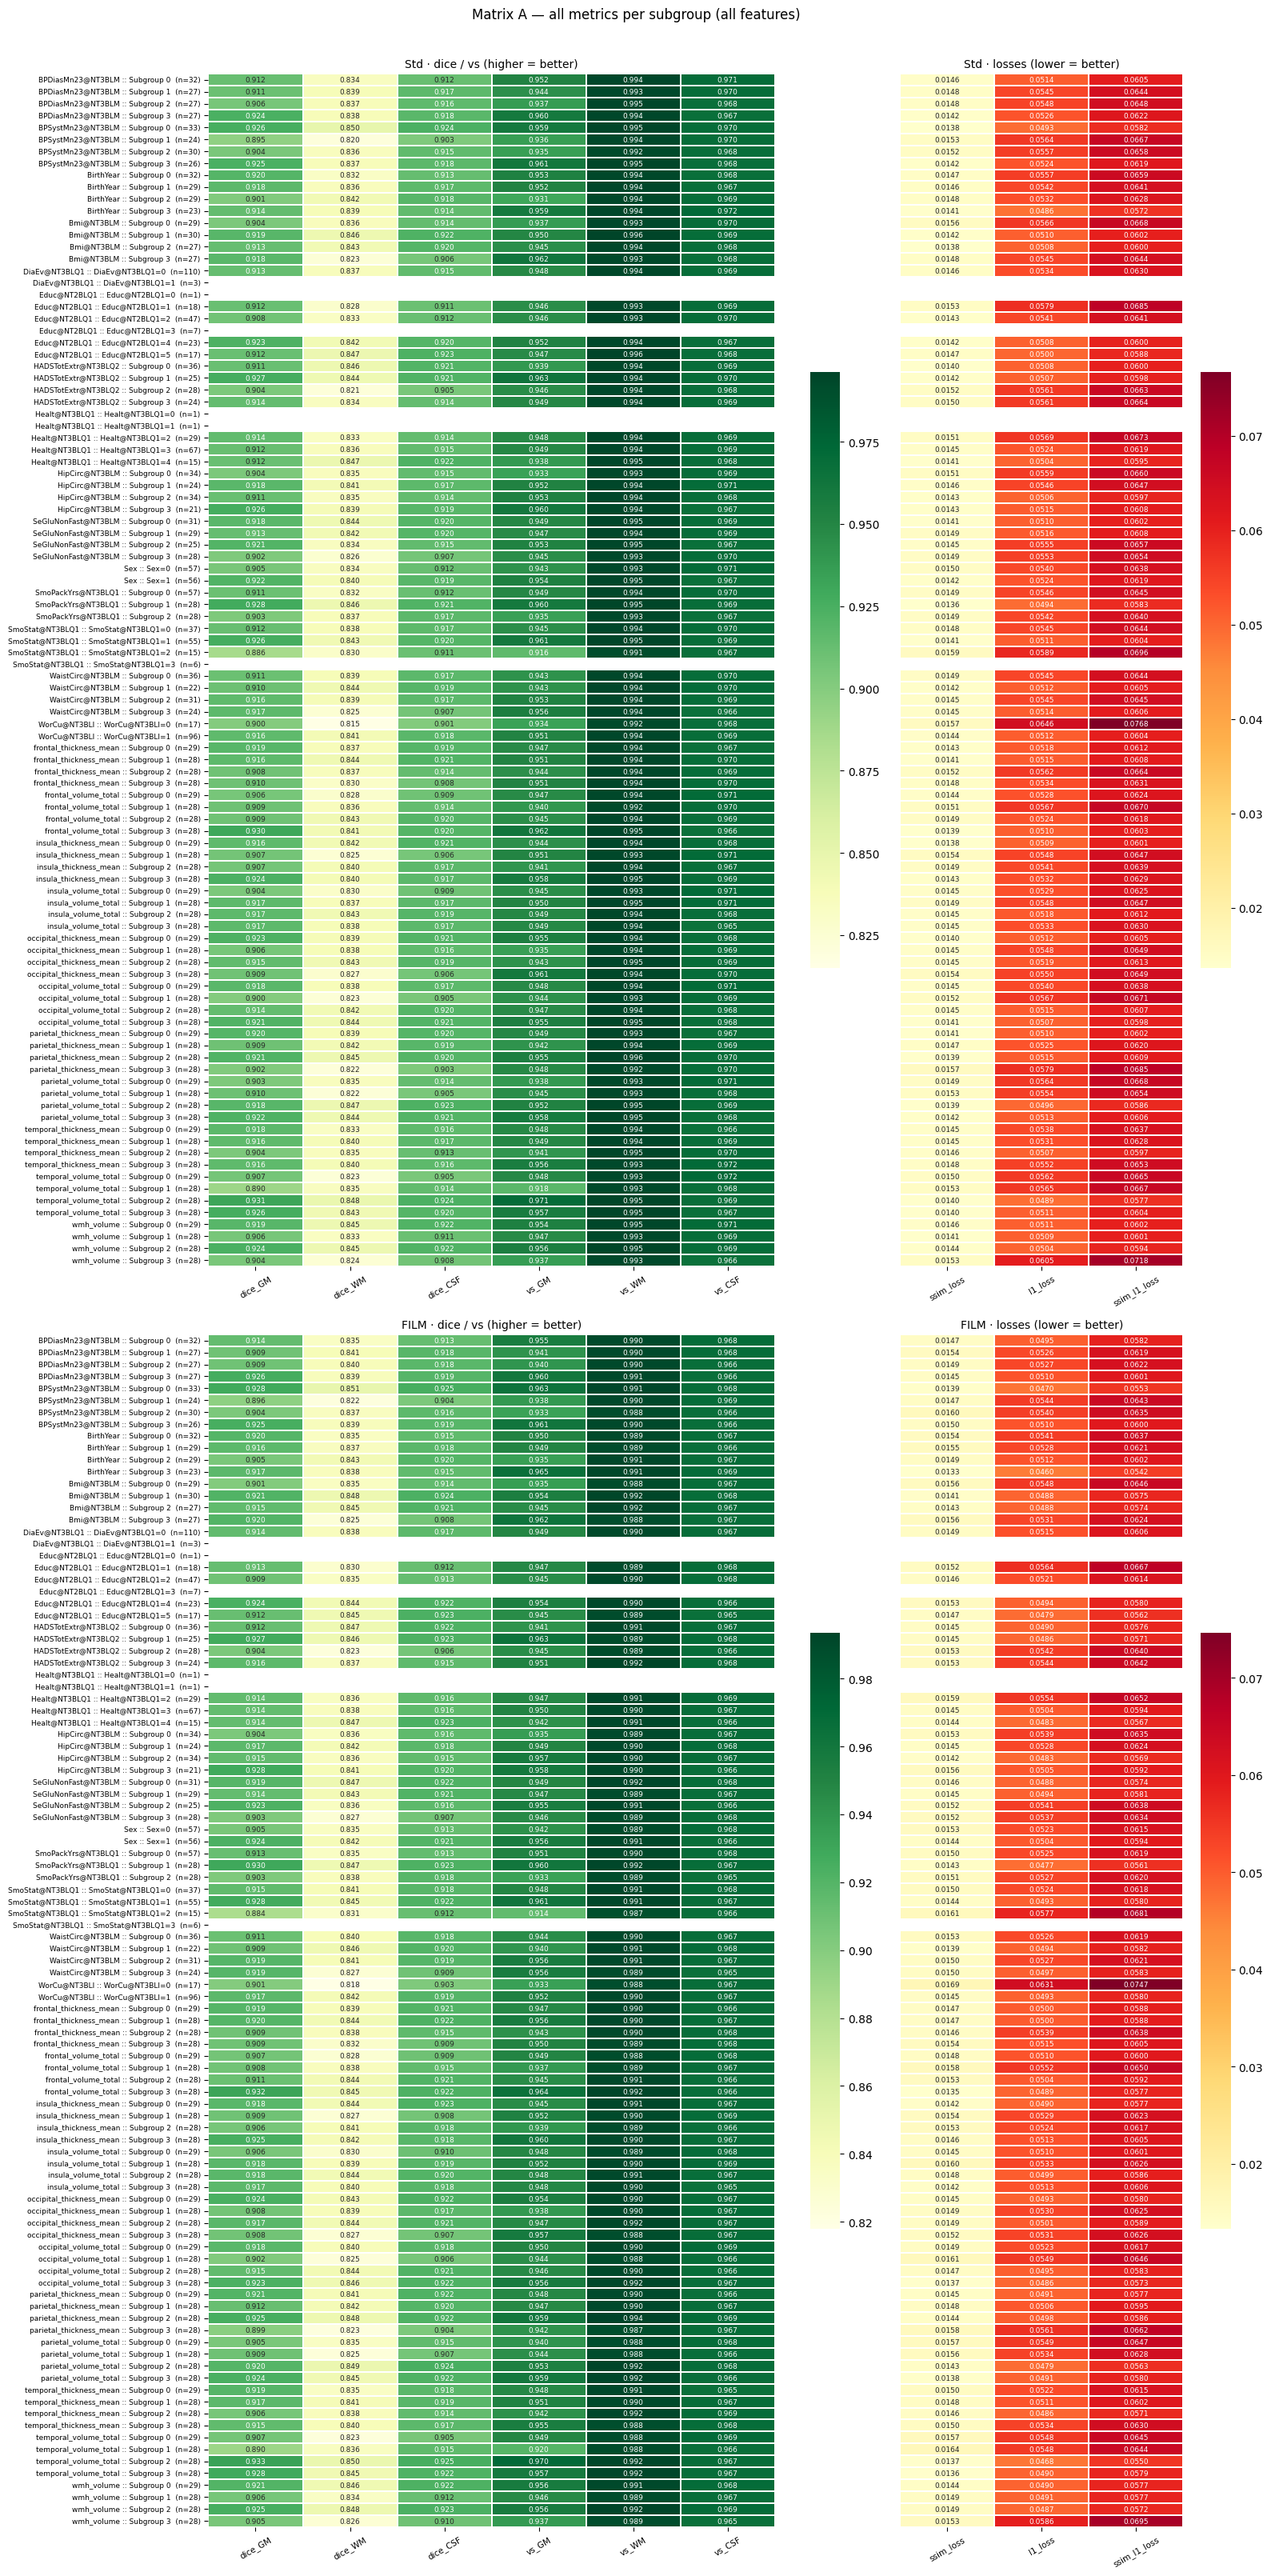

In [11]:
matrixA_panels = plot_subgroup_heatmap(
    summary, ALL_FEATURES,
    title='Matrix A — all metrics per subgroup (all features)',
    savepath=FIG_DIR / 'matrixA_heatmap_all_features.png',
)


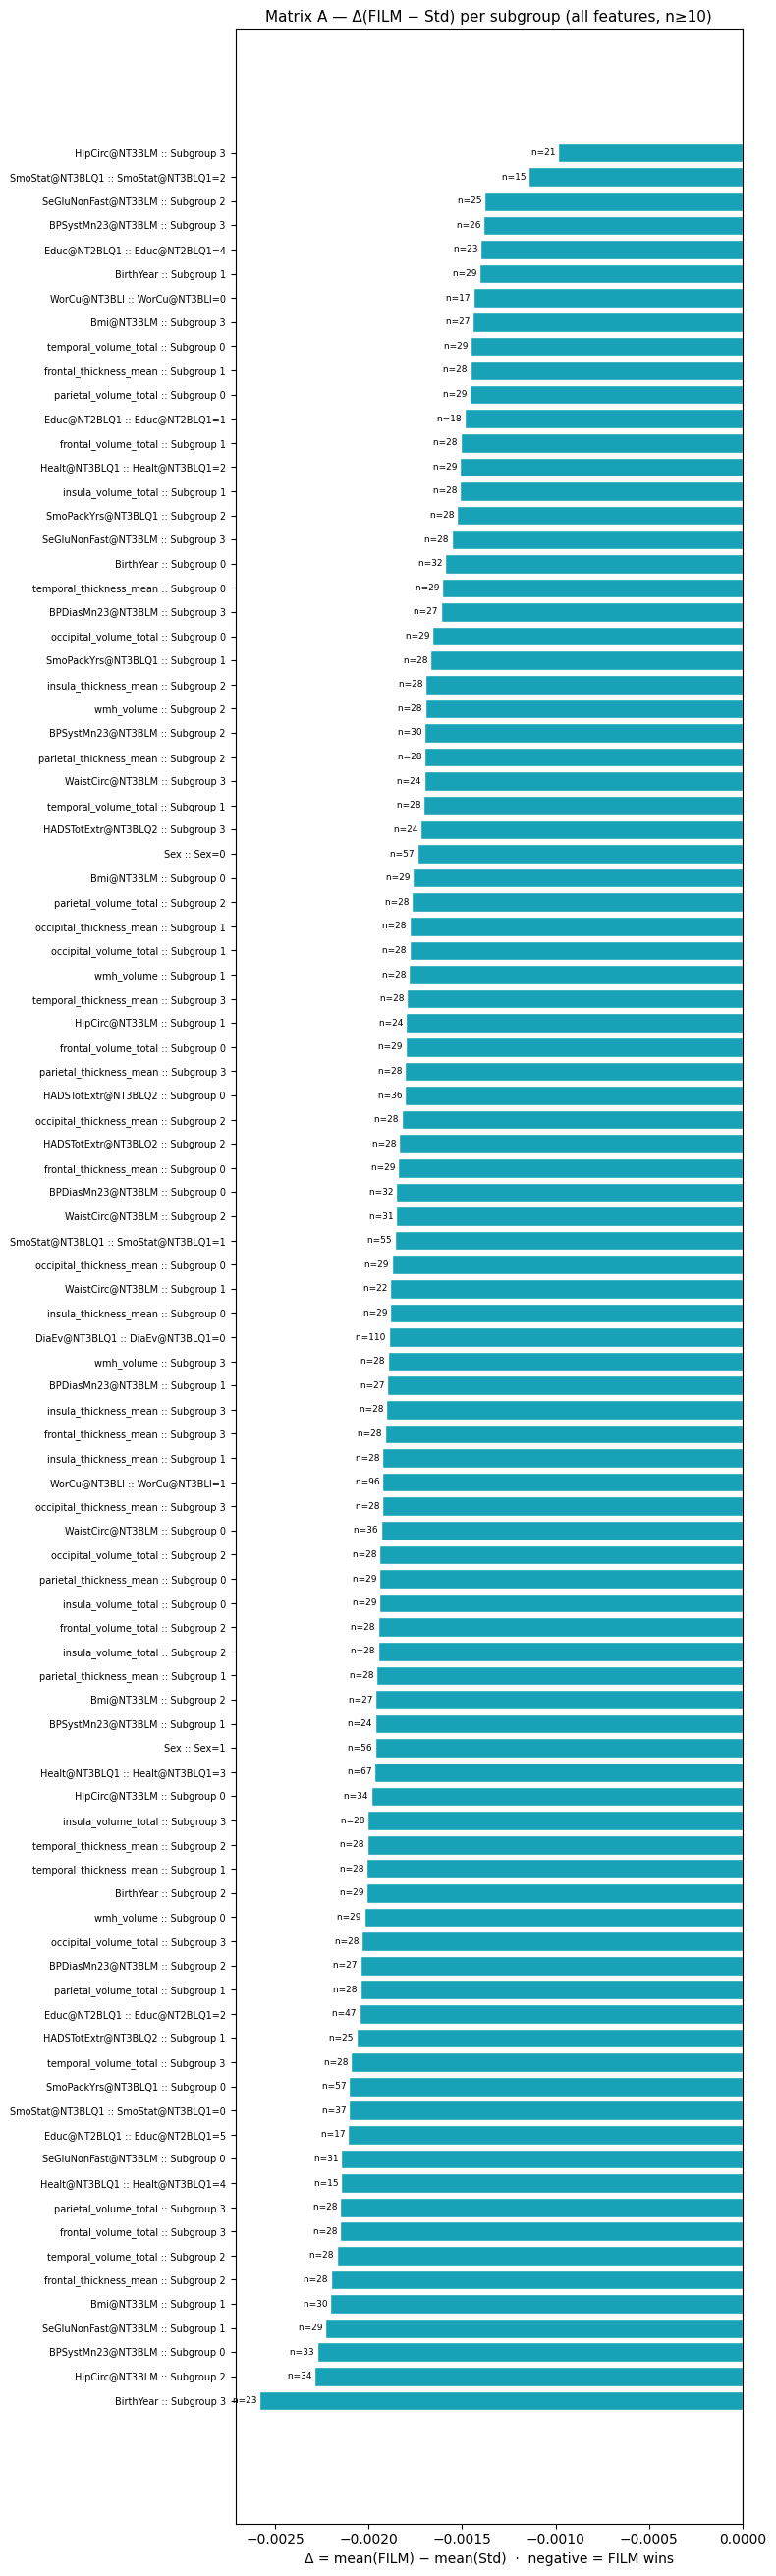

In [12]:
delta_sorted_A = plot_delta_bar(
    deltas, ALL_FEATURES,
    title='Matrix A — Δ(FILM − Std) per subgroup (all features, n≥{})'.format(N_MIN),
    savepath=FIG_DIR / 'matrixA_delta_bar_all_features.png',
)


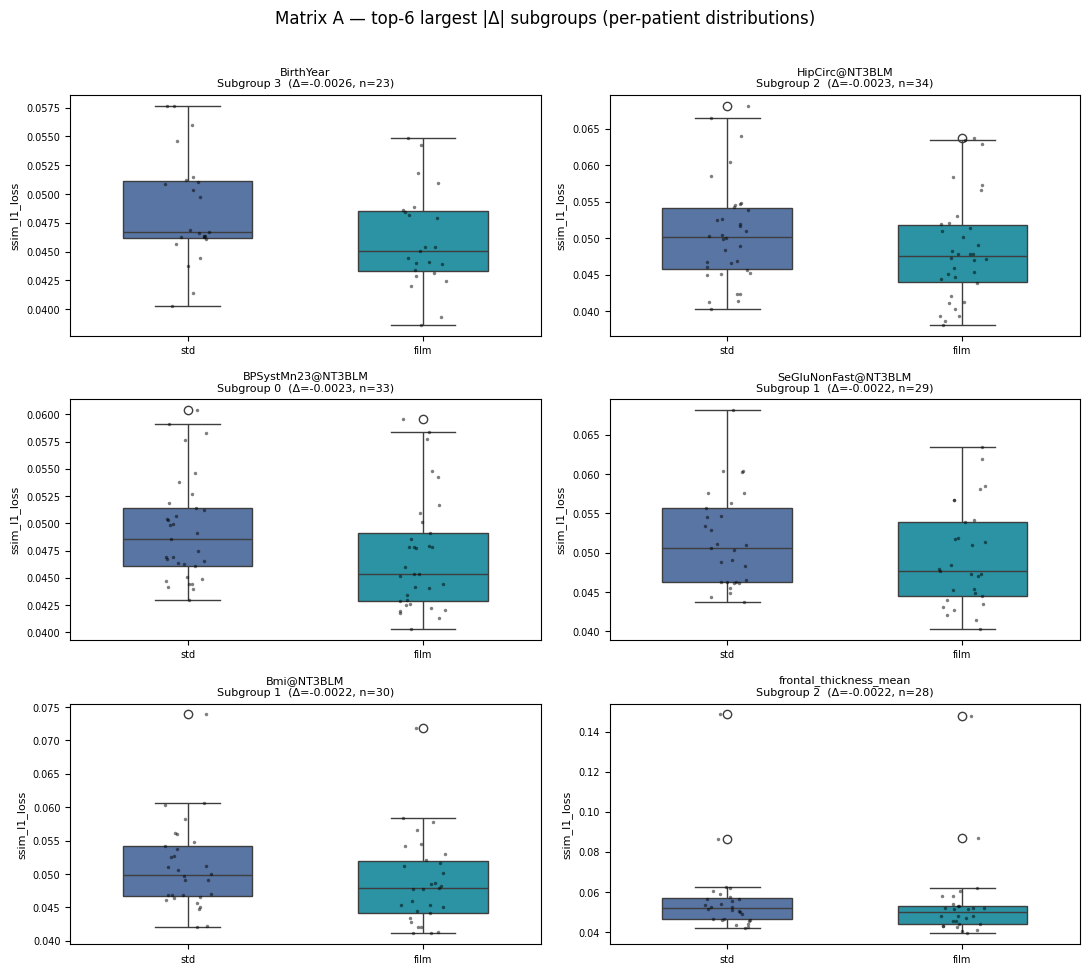

In [13]:
top_diff_A = plot_top_diff_boxplots(
    deltas, subgroups_long, losses, ALL_FEATURES, top_k=6,
    title='Matrix A — top-6 largest |Δ| subgroups (per-patient distributions)',
    savepath=FIG_DIR / 'matrixA_top_diff_boxplots.png',
)


## 9 — Matrix B: subgroups over the **22 FILM features only**


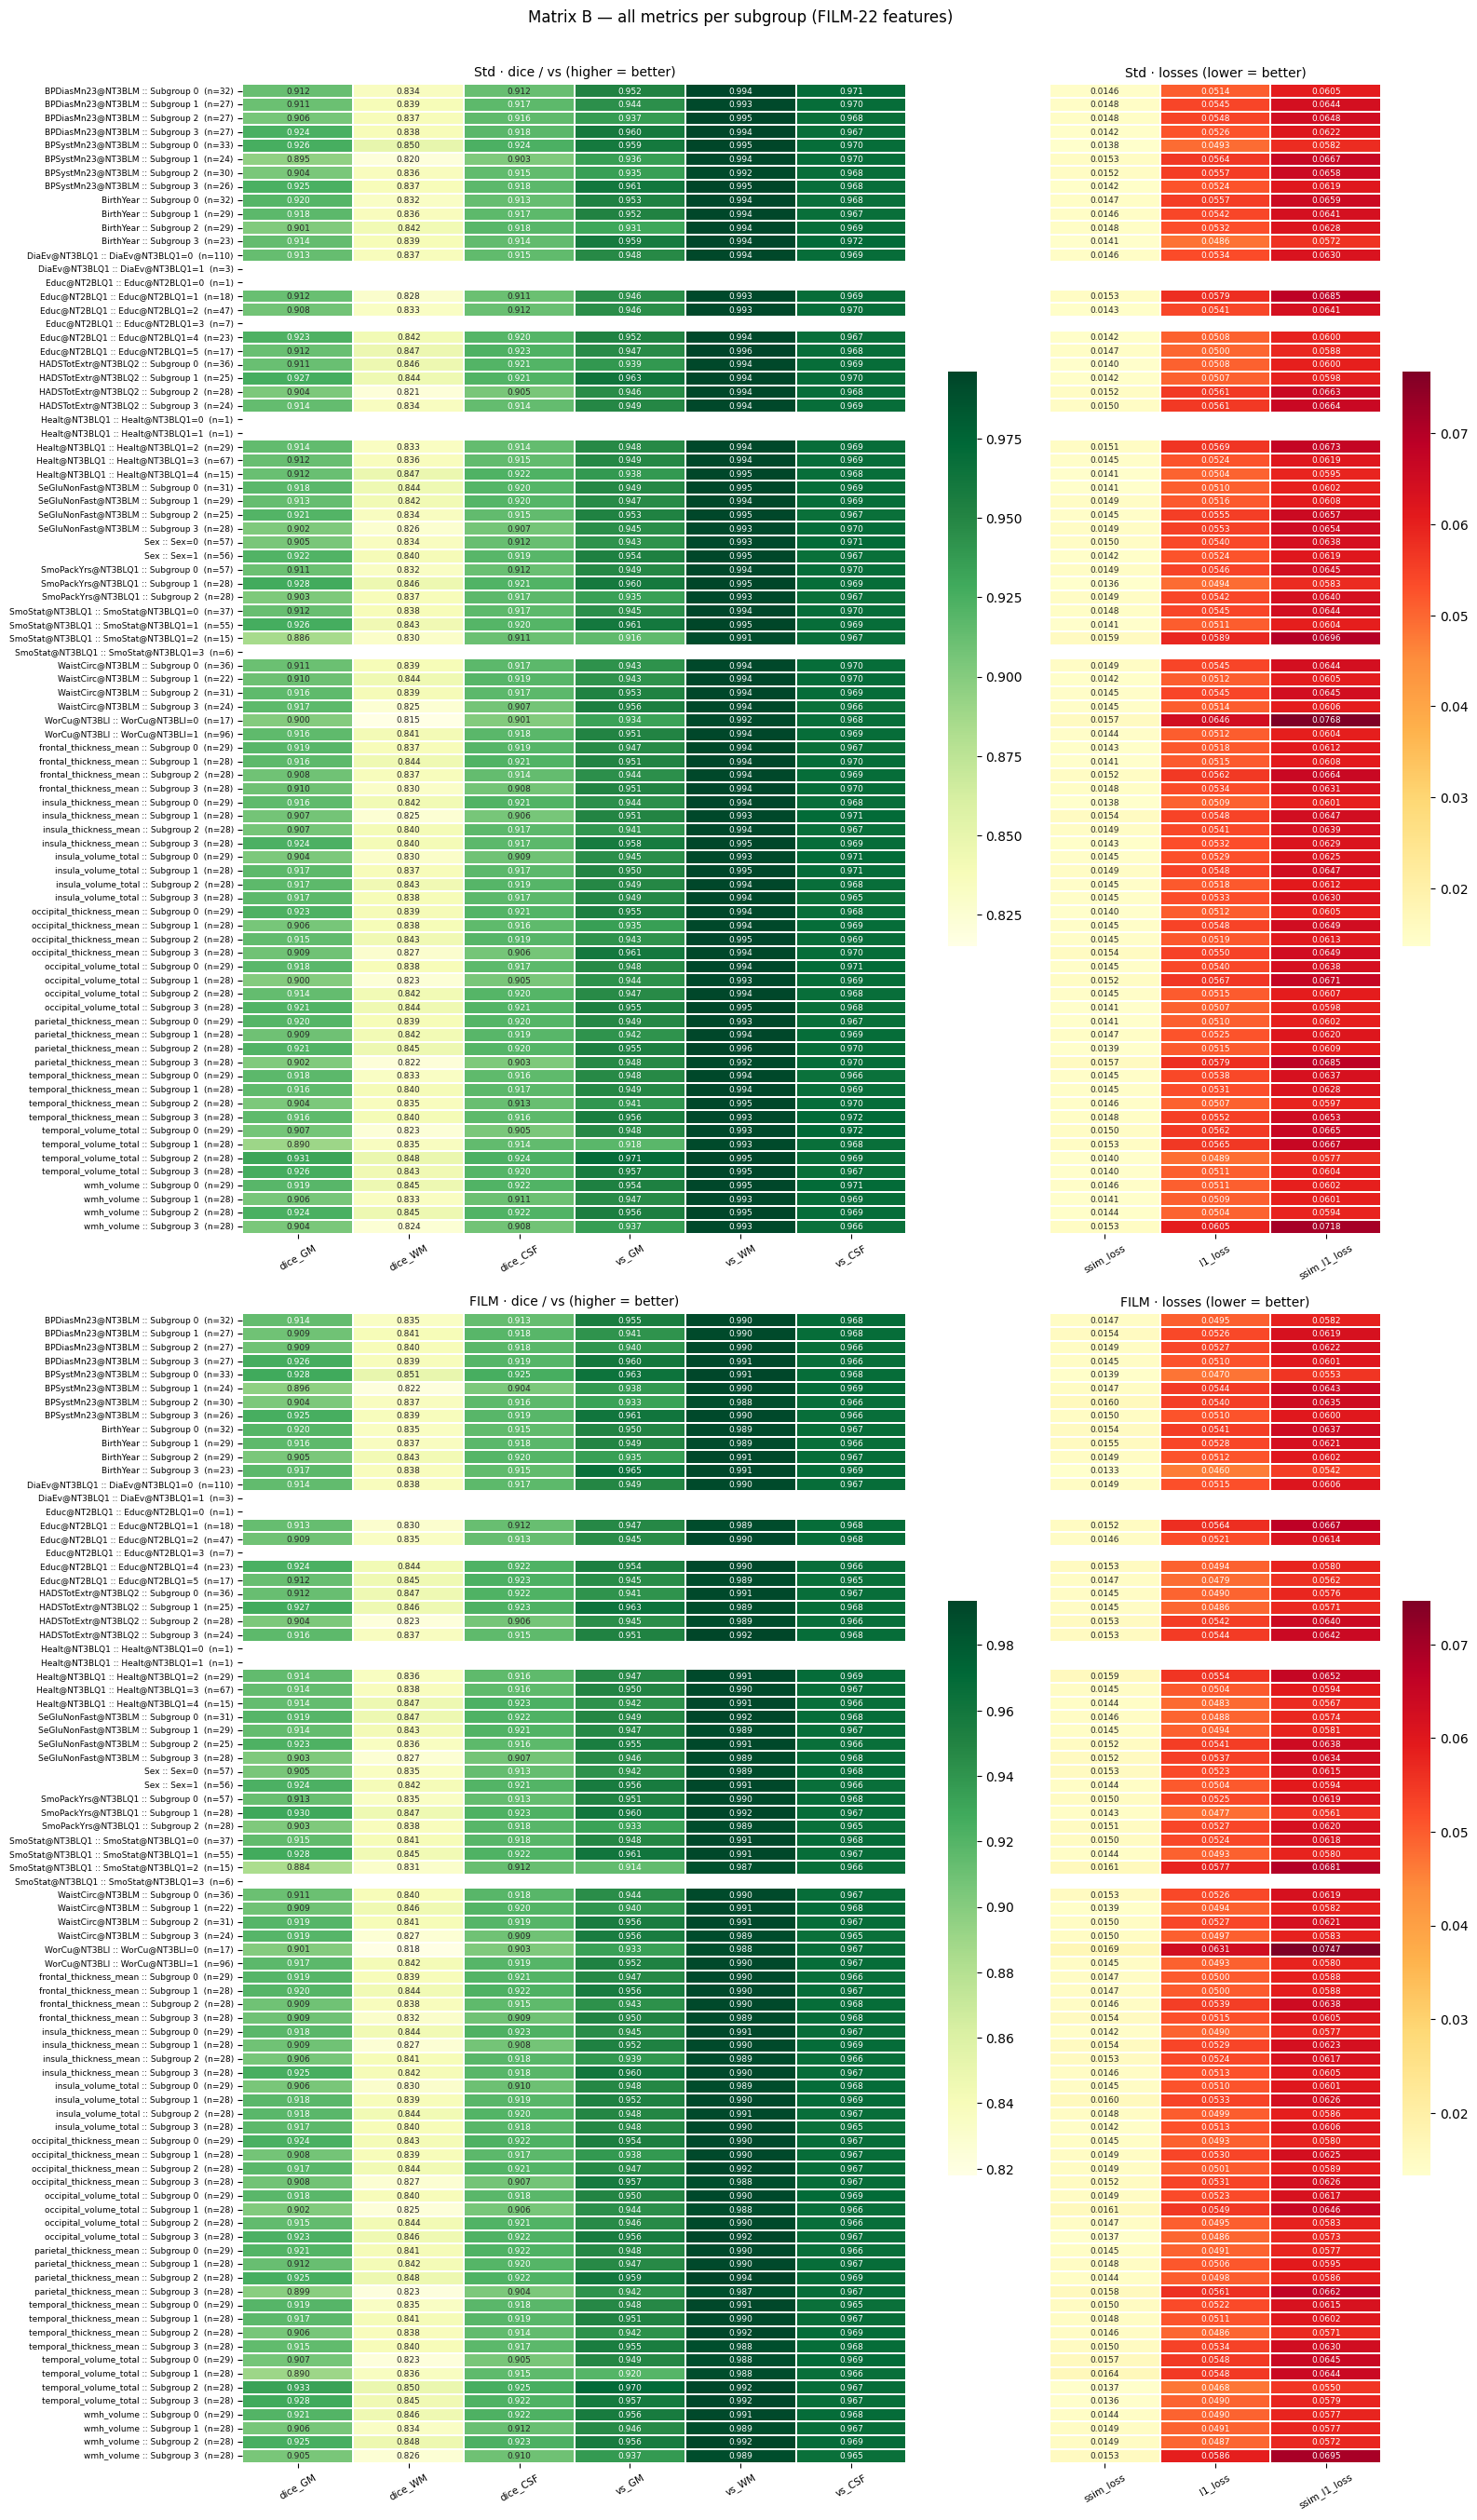

In [14]:
matrixB_panels = plot_subgroup_heatmap(
    summary, FILM_22,
    title='Matrix B — all metrics per subgroup (FILM-22 features)',
    savepath=FIG_DIR / 'matrixB_heatmap_film22.png',
)


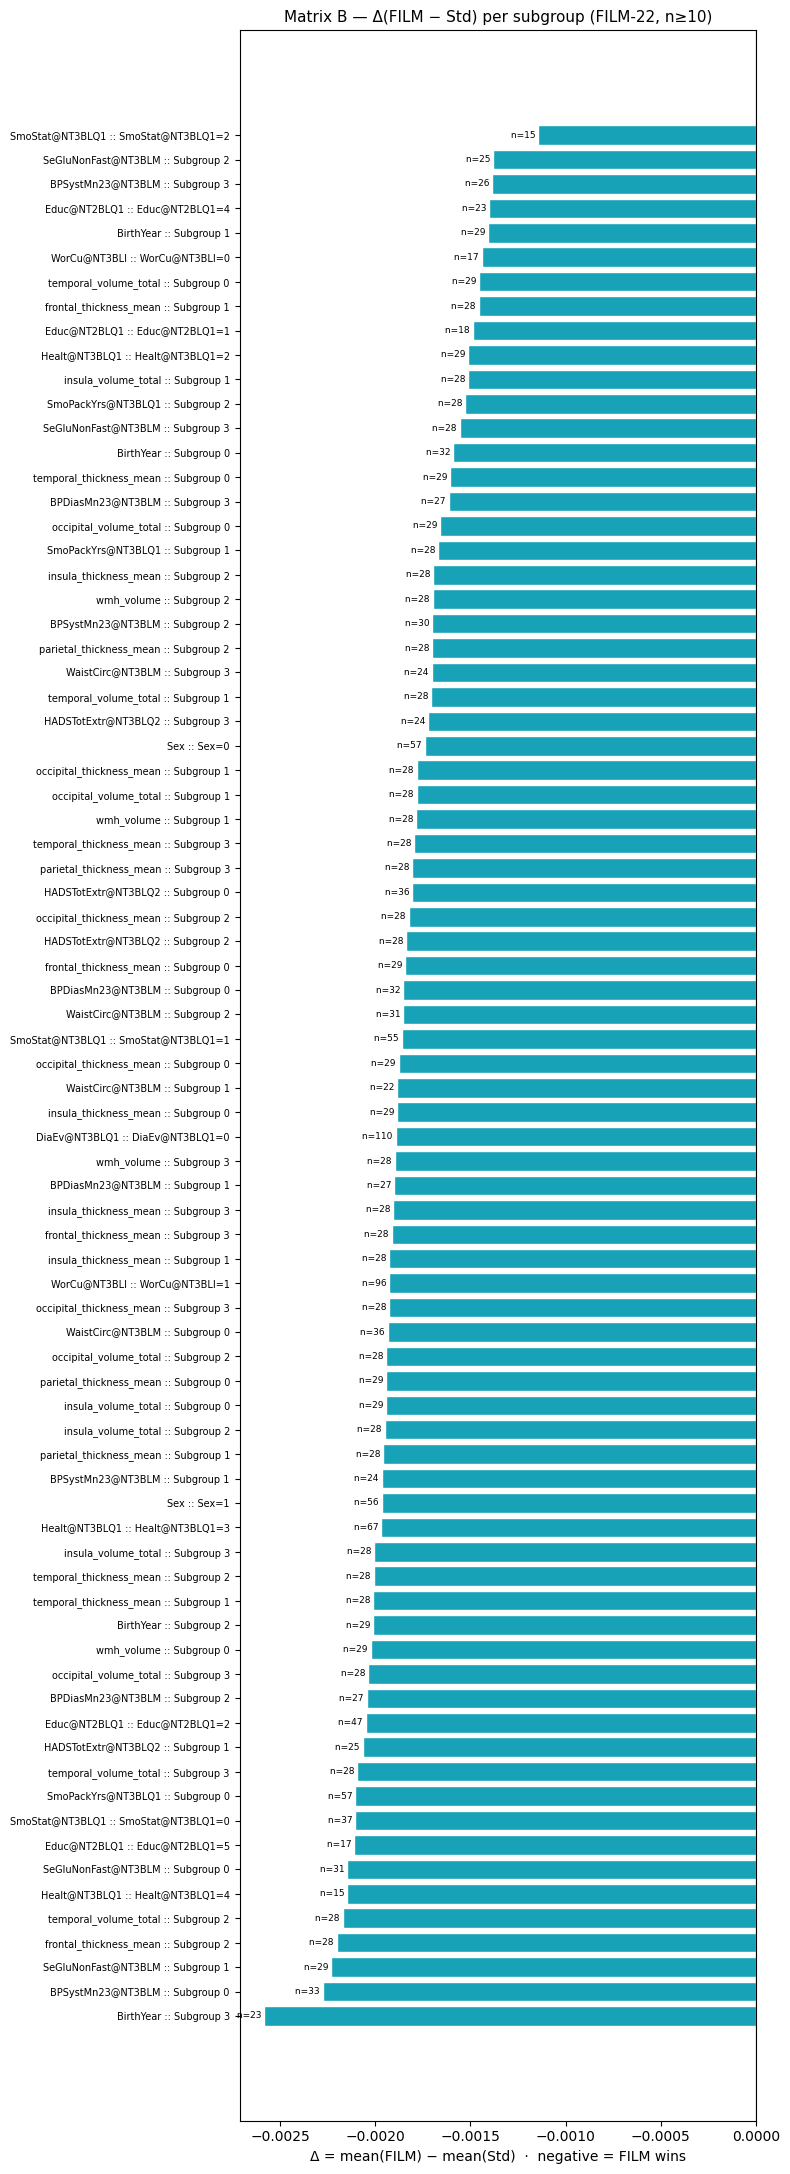

In [15]:
delta_sorted_B = plot_delta_bar(
    deltas, FILM_22,
    title='Matrix B — Δ(FILM − Std) per subgroup (FILM-22, n≥{})'.format(N_MIN),
    savepath=FIG_DIR / 'matrixB_delta_bar_film22.png',
)


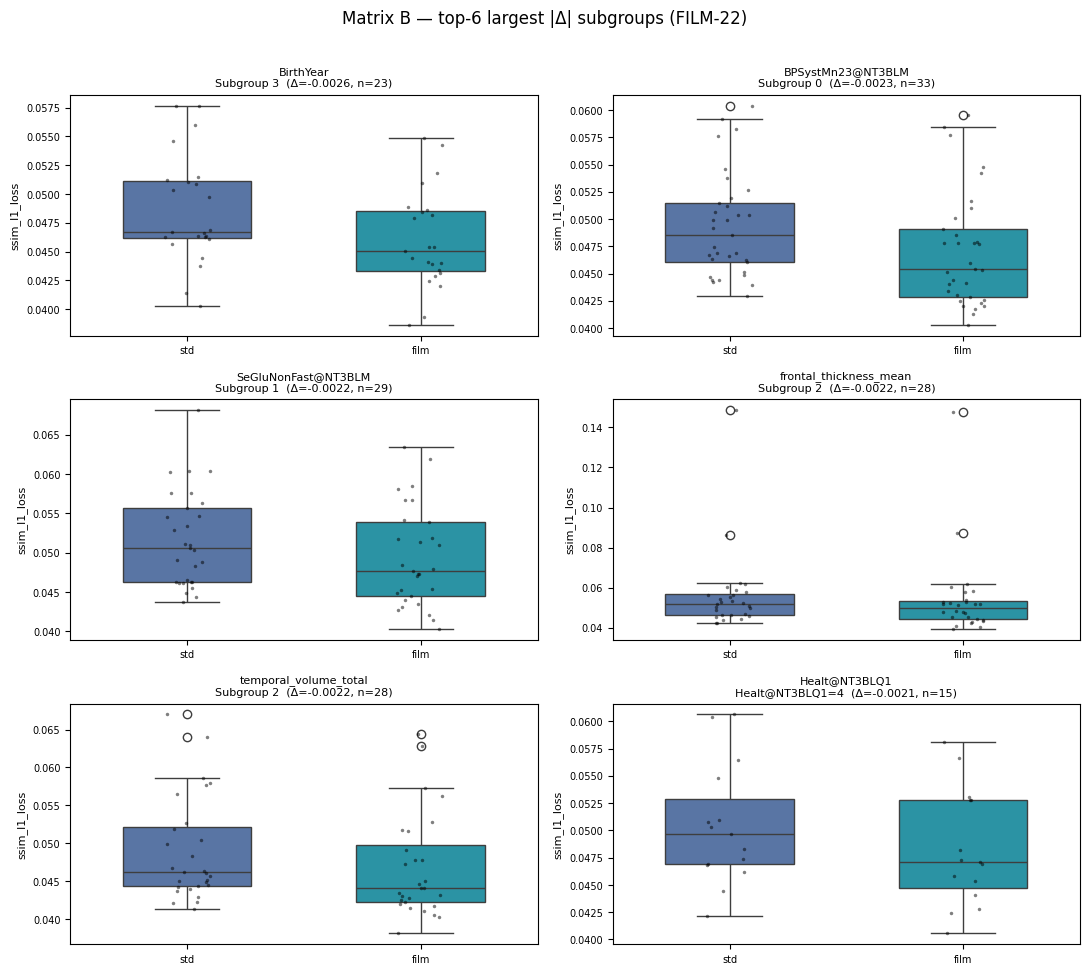

In [16]:
top_diff_B = plot_top_diff_boxplots(
    deltas, subgroups_long, losses, FILM_22, top_k=6,
    title='Matrix B — top-6 largest |Δ| subgroups (FILM-22)',
    savepath=FIG_DIR / 'matrixB_top_diff_boxplots.png',
)


## 10 — Findings: where do the models do worst / best?

Worst subgroups for each model (highest mean `ssim_l1_loss`) and the largest
FILM wins / regressions, restricted to subgroups with `n ≥ 10`.

In [17]:
def _worst_subgroups(summary, model, features, top=10):
    sub = summary[(summary.model == model) & (summary['feature'].isin(features))
                  & (summary.n >= N_MIN)]
    cols = ['feature','subgroup_label','mean_loss','std_loss','n']
    return sub.nlargest(top, 'mean_loss')[cols].reset_index(drop=True)

print('Worst subgroups — std model (all features):')
print(_worst_subgroups(summary, 'std',  ALL_FEATURES).to_string(index=False))
print()
print('Worst subgroups — FILM model (all features):')
print(_worst_subgroups(summary, 'film', ALL_FEATURES).to_string(index=False))


Worst subgroups — std model (all features):
                feature    subgroup_label  mean_loss  std_loss  n
           WorCu@NT3BLI    WorCu@NT3BLI=0   0.064555  0.025298 17
             wmh_volume        Subgroup 3   0.060530  0.021991 28
        SmoStat@NT3BLQ1 SmoStat@NT3BLQ1=2   0.058870  0.012183 15
parietal_thickness_mean        Subgroup 3   0.057923  0.020525 28
           Educ@NT2BLQ1    Educ@NT2BLQ1=1   0.057853  0.012983 18
          Healt@NT3BLQ1   Healt@NT3BLQ1=2   0.056870  0.013039 29
 occipital_volume_total        Subgroup 1   0.056697  0.020582 28
   frontal_volume_total        Subgroup 1   0.056663  0.020463 28
             Bmi@NT3BLM        Subgroup 0   0.056562  0.015694 29
  temporal_volume_total        Subgroup 1   0.056464  0.014173 28

Worst subgroups — FILM model (all features):
                feature    subgroup_label  mean_loss  std_loss  n
           WorCu@NT3BLI    WorCu@NT3BLI=0   0.063113  0.025423 17
             wmh_volume        Subgroup 3   0.058631

In [18]:
def _biggest_smallest_wins(deltas, features, top=10):
    sub = deltas[(deltas['feature'].isin(features)) & (deltas['n'] >= N_MIN)]
    cols = ['feature','subgroup_label','mean_delta','mean_std_loss','mean_film_loss','n']
    biggest  = sub.nsmallest(top, 'mean_delta')[cols].reset_index(drop=True)
    smallest = sub.nlargest(top,  'mean_delta')[cols].reset_index(drop=True)
    return biggest, smallest

big_A, small_A = _biggest_smallest_wins(deltas, ALL_FEATURES)
n_pos = (deltas[(deltas['feature'].isin(ALL_FEATURES)) & (deltas['n'] >= N_MIN)]['mean_delta'] > 0).sum()
print(f'Subgroups where FILM under-performs (Δ > 0): {n_pos}')
print()
print('Biggest FILM wins (all features, Δ most negative):')
print(big_A.to_string(index=False))
print()
print('Smallest FILM wins (all features, Δ closest to 0 or positive):')
print(small_A.to_string(index=False))


Subgroups where FILM under-performs (Δ > 0): 0

Biggest FILM wins (all features, Δ most negative):
               feature  subgroup_label  mean_delta  mean_std_loss  mean_film_loss  n
             BirthYear      Subgroup 3   -0.002584       0.048578        0.045994 23
        HipCirc@NT3BLM      Subgroup 2   -0.002291       0.050623        0.048332 34
     BPSystMn23@NT3BLM      Subgroup 0   -0.002278       0.049323        0.047046 33
   SeGluNonFast@NT3BLM      Subgroup 1   -0.002232       0.051623        0.049391 29
            Bmi@NT3BLM      Subgroup 1   -0.002207       0.051011        0.048805 30
frontal_thickness_mean      Subgroup 2   -0.002202       0.056151        0.053949 28
 temporal_volume_total      Subgroup 2   -0.002173       0.048932        0.046759 28
  frontal_volume_total      Subgroup 3   -0.002153       0.051008        0.048855 28
 parietal_volume_total      Subgroup 3   -0.002152       0.051294        0.049142 28
         Healt@NT3BLQ1 Healt@NT3BLQ1=4   -0.002149 

In [19]:
big_B, small_B = _biggest_smallest_wins(deltas, FILM_22)
n_pos_B = (deltas[(deltas['feature'].isin(FILM_22)) & (deltas['n'] >= N_MIN)]['mean_delta'] > 0).sum()
print(f'Subgroups where FILM under-performs in FILM-22 set (Δ > 0): {n_pos_B}')
print()
print('Biggest FILM wins (FILM-22, Δ most negative):')
print(big_B.to_string(index=False))
print()
print('Smallest FILM wins (FILM-22, Δ closest to 0 or positive):')
print(small_B.to_string(index=False))


Subgroups where FILM under-performs in FILM-22 set (Δ > 0): 0

Biggest FILM wins (FILM-22, Δ most negative):
               feature    subgroup_label  mean_delta  mean_std_loss  mean_film_loss  n
             BirthYear        Subgroup 3   -0.002584       0.048578        0.045994 23
     BPSystMn23@NT3BLM        Subgroup 0   -0.002278       0.049323        0.047046 33
   SeGluNonFast@NT3BLM        Subgroup 1   -0.002232       0.051623        0.049391 29
frontal_thickness_mean        Subgroup 2   -0.002202       0.056151        0.053949 28
 temporal_volume_total        Subgroup 2   -0.002173       0.048932        0.046759 28
         Healt@NT3BLQ1   Healt@NT3BLQ1=4   -0.002149       0.050410        0.048261 15
   SeGluNonFast@NT3BLM        Subgroup 0   -0.002149       0.050991        0.048842 31
          Educ@NT2BLQ1    Educ@NT2BLQ1=5   -0.002111       0.049989        0.047878 17
       SmoStat@NT3BLQ1 SmoStat@NT3BLQ1=0   -0.002105       0.054518        0.052414 37
    SmoPackYrs@NT3BLQ

### Overall paired comparison

Patient-level paired t-test (and effect size) on the 113 shared patients.

In [20]:
from scipy import stats

wide = (losses.pivot_table(index='hunt_id', columns='model',
                           values='ssim_l1_loss')
              .rename(columns={'std':'loss_std','film':'loss_film'}))
delta_per_patient = wide['loss_film'] - wide['loss_std']
t, p = stats.ttest_rel(wide['loss_film'], wide['loss_std'])
print(f'Overall mean loss  | std={wide.loss_std.mean():.5f}  film={wide.loss_film.mean():.5f}')
print(f'Mean paired Δ      | {delta_per_patient.mean():+.5f}  (sd={delta_per_patient.std():.5f})')
print(f'Paired t-test      | t={t:.3f}, p={p:.4g}, n={len(wide)}')
print(f"FILM wins on        | {(delta_per_patient < 0).sum()} / {len(delta_per_patient)} patients")


Overall mean loss  | std=0.05321  film=0.05136
Mean paired Δ      | -0.00185  (sd=0.00164)
Paired t-test      | t=-11.991, p=8.195e-22, n=113
FILM wins on        | 103 / 113 patients


---
### Saved figures

All matrix plots are written to `out/overleaf_figures/ex4/`:
- `matrixA_heatmap_all_features.png`
- `matrixA_delta_bar_all_features.png`
- `matrixA_top_diff_boxplots.png`
- `matrixB_heatmap_film22.png`
- `matrixB_delta_bar_film22.png`
- `matrixB_top_diff_boxplots.png`
